In [2]:
# %% 데이터 로드
import glob, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# seaborn 스타일을 먼저 적용 (이게 폰트를 덮어쓸 수 있어서 순서 중요!)
sns.set_style('whitegrid')

# 그 다음 한글 폰트 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 출력 옵션
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:,.2f}'.format)
 
from pathlib import Path
 
current = Path.cwd()
project_root = current if (current / 'data').exists() else current.parent
 
# ── 추정매출 로드 (기존 코드 재사용) ──
DATA_DIR = str(project_root / 'data' / 'extracted' / '서울시_상권분석서비스(추정매출+영역)') + '/'
pattern = DATA_DIR + '*추정매출*.csv'
sales_files = sorted(glob.glob(pattern))
print(f'추정매출 파일: {len(sales_files)}개')
 
sales = pd.concat(
    [pd.read_csv(f, encoding='cp949', low_memory=False) for f in sales_files],
    ignore_index=True
)
print(f'  → 통합: {sales.shape[0]:,}행 × {sales.shape[1]}컬럼')
 
# ── 영역 로드 ──
area_path = glob.glob(DATA_DIR + '*영역*상권*.csv')[0]
area = pd.read_csv(area_path, encoding='cp949')
print(f'영역: {area.shape[0]:,}개 상권')
 
# ── 길단위인구(유동인구) 로드 ──
floating_path = project_root / 'data' / 'extracted' / '서울시 상권분석서비스(길단위인구-상권)' / '서울시 상권분석서비스(길단위인구-상권).csv'
floating = pd.read_csv(floating_path, encoding='cp949')
print(f'유동인구: {floating.shape[0]:,}행 × {floating.shape[1]}컬럼')
 
# ── 직장인구 로드 ──
work_path = project_root / 'data' / '06_직장인구' / '서울시 상권분석서비스(직장인구-상권).csv'
df_직장 = pd.read_csv(work_path, encoding='cp949')
print(f'직장인구: {df_직장.shape[0]:,}행 × {df_직장.shape[1]}컬럼')
 
# ── 상주인구 로드 ──
resident_path = project_root / 'data' / '07_상주인구' / '서울시 상권분석서비스(상주인구-상권).csv'
df_상주 = pd.read_csv(resident_path, encoding='cp949')
print(f'상주인구: {df_상주.shape[0]:,}행 × {df_상주.shape[1]}컬럼')
 
print('\n✅ 전체 데이터 로드 완료')

추정매출 파일: 6개
  → 통합: 519,931행 × 55컬럼
영역: 1,650개 상권
유동인구: 46,184행 × 27컬럼
직장인구: 45,840행 × 26컬럼
상주인구: 40,812행 × 29컬럼

✅ 전체 데이터 로드 완료


In [4]:
# %% 컬럼 정의 및 데이터 준비
상권 = ['골목상권', '발달상권', '관광특구', '전통시장']
 
# ── 전통시장 특화 업종 정의 ──
전통시장_업종 = ['수산물판매', '청과상', '육류판매', '미곡판매', '반찬가게', '한복점']
 
# ── 50대+ 상주인구 비율 ──
df_상주['50대이상_비율'] = (
    df_상주['연령대_50_상주인구_수'] + df_상주['연령대_60_이상_상주인구_수']
) / df_상주['총_상주인구_수'].replace(0, np.nan) * 100


In [5]:
# ── 상권별 전체 매출 + 전통업종 매출 ──
전체매출_5 = sales.groupby(
    ['기준_년분기_코드', '상권_코드', '상권_구분_코드_명']
)['당월_매출_금액'].sum().reset_index()
전체매출_5.rename(columns={'당월_매출_금액': '전체_매출'}, inplace=True)
 
전통업종매출 = sales[sales['서비스_업종_코드_명'].isin(전통시장_업종)].groupby(
    ['기준_년분기_코드', '상권_코드']
)['당월_매출_금액'].sum().reset_index()
전통업종매출.rename(columns={'당월_매출_금액': '전통업종_매출'}, inplace=True)
 
전체매출_5 = 전체매출_5.merge(전통업종매출, on=['기준_년분기_코드', '상권_코드'], how='left').fillna(0)
전체매출_5['전통업종_비중'] = 전체매출_5['전통업종_매출'] / 전체매출_5['전체_매출'] * 100

In [6]:
# ── 상주인구 merge ──
merged_50 = 전체매출_5.merge(
    df_상주[['기준_년분기_코드', '상권_코드', '50대이상_비율', '총_상주인구_수']],
    on=['기준_년분기_코드', '상권_코드'], how='inner'
)

In [8]:
# %% 상관계수 분석
print('📊 상권구분별 50대+ 상주인구 비율 vs 전통업종 비중')
print('-' * 65)
print(f'{"유형":<10} {"50대+비율":>10} {"전통업종비중":>12} {"상관계수":>10} {"평균매출(억)":>12}')
print('-' * 65)
for 구분 in 상권:
    sub = merged_50[merged_50['상권_구분_코드_명'] == 구분]
    corr = sub[['50대이상_비율', '전통업종_비중']].corr().iloc[0, 1]
    print(f'{구분:<10} {sub["50대이상_비율"].mean():>9.1f}%'
          f' {sub["전통업종_비중"].mean():>11.1f}%'
          f' {corr:>9.3f}'
          f' {sub["전체_매출"].mean()/1e8:>11.1f}')

📊 상권구분별 50대+ 상주인구 비율 vs 전통업종 비중
-----------------------------------------------------------------
유형             50대+비율       전통업종비중       상관계수      평균매출(억)
-----------------------------------------------------------------
골목상권            43.2%         4.3%     0.075        36.7
발달상권            37.8%         3.2%    -0.089       537.9
관광특구            50.6%         2.1%     0.548      2048.3
전통시장            51.3%        27.2%     0.109       113.8


In [9]:
# %% 5분위 분석
merged_50['50대_구간'], bins = pd.qcut(
    merged_50['50대이상_비율'].dropna(), q=5, retbins=True, duplicates='drop'
)
라벨 = [f'{bins[i]:.0f}~{bins[i+1]:.0f}%' for i in range(len(bins)-2)]
라벨.append(f'{bins[-2]:.0f}% 이상')
merged_50['50대_구간'] = pd.qcut(
    merged_50['50대이상_비율'].dropna(), q=5, labels=라벨, duplicates='drop'
)
 
구간별 = merged_50.groupby('50대_구간').agg(
    평균50대=('50대이상_비율', 'mean'),
    전통업종비중=('전통업종_비중', 'mean'),
    전체매출=('전체_매출', 'mean'),
    n=('상권_코드', 'count')
).reset_index()

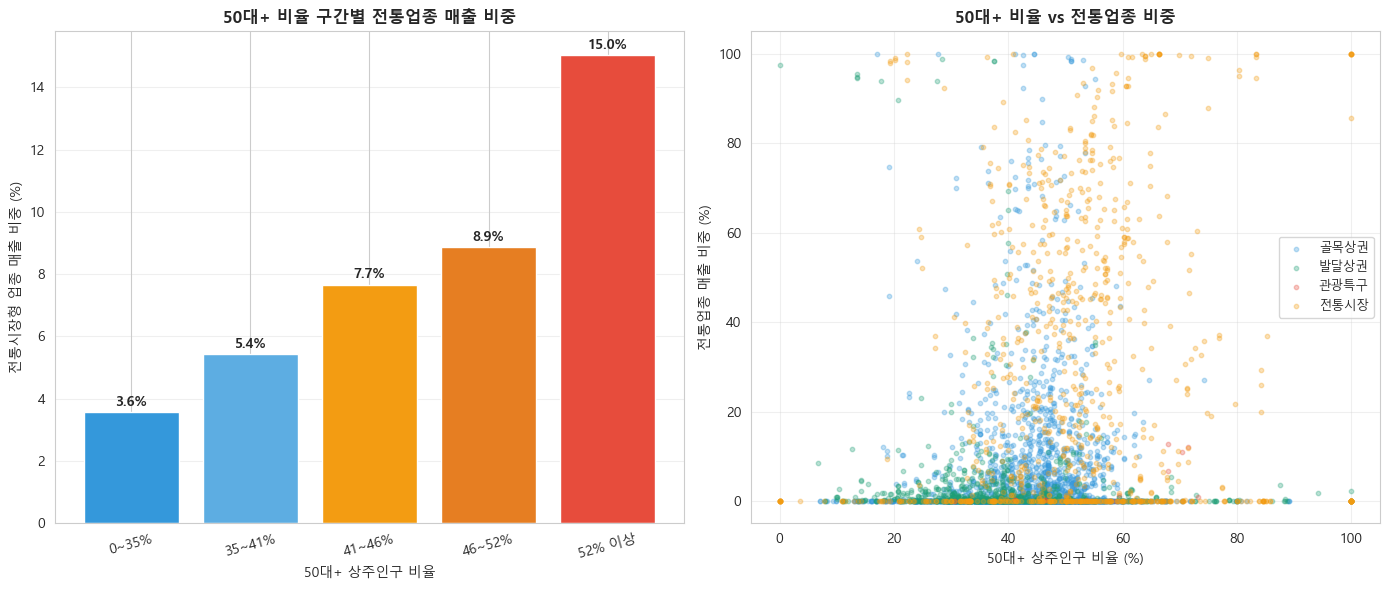

In [11]:
# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
# (1) 전통업종 비중
ax1 = axes[0]
colors = ['#3498DB', '#5DADE2', '#F39C12', '#E67E22', '#E74C3C']
bars = ax1.bar(구간별['50대_구간'], 구간별['전통업종비중'], color=colors, edgecolor='white')
ax1.set_ylabel('전통시장형 업종 매출 비중 (%)')
ax1.set_xlabel('50대+ 상주인구 비율')
ax1.set_title('50대+ 비율 구간별 전통업종 매출 비중', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
ax1.tick_params(axis='x', rotation=15)
 
for bar, val in zip(bars, 구간별['전통업종비중']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)
 
# (2) 상권구분별 산점도
ax2 = axes[1]
색_map = {'골목상권':'#3498DB', '발달상권':'#1D9E75', '관광특구':'#E74C3C', '전통시장':'#F39C12'}
sample = merged_50.sample(n=min(5000, len(merged_50)), random_state=42)
for 구분 in 상권:
    sub = sample[sample['상권_구분_코드_명'] == 구분]
    ax2.scatter(sub['50대이상_비율'], sub['전통업종_비중'],
                alpha=0.3, s=10, color=색_map[구분], label=구분)
ax2.set_xlabel('50대+ 상주인구 비율 (%)')
ax2.set_ylabel('전통업종 매출 비중 (%)')
ax2.set_title('50대+ 비율 vs 전통업종 비중', fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)
 
plt.tight_layout()
plt.show()

In [12]:
# %% 전통시장 내부 3분위
전통_only = merged_50[merged_50['상권_구분_코드_명'] == '전통시장'].copy()
전통_only['50대_수준'] = pd.qcut(
    전통_only['50대이상_비율'].dropna(), q=3,
    labels=['50대+ 적음', '50대+ 보통', '50대+ 많음'], duplicates='drop'
)
 
전통구간 = 전통_only.groupby('50대_수준').agg(
    평균50대=('50대이상_비율', 'mean'),
    전통업종=('전통업종_비중', 'mean'),
    전체매출억=('전체_매출', lambda x: x.mean()/1e8),
    n=('상권_코드', 'count')
).reset_index()
 
print('📊 전통시장 내부: 50대+ 비율별 매출 구조')
print('-' * 55)
for _, row in 전통구간.iterrows():
    print(f'  {row["50대_수준"]}: 50대+={row["평균50대"]:.1f}%'
          f' | 전통업종={row["전통업종"]:.1f}% | 매출={row["전체매출억"]:.1f}억 (n={row["n"]:,})')

📊 전통시장 내부: 50대+ 비율별 매출 구조
-------------------------------------------------------
  50대+ 적음: 50대+=35.3% | 전통업종=21.6% | 매출=124.0억 (n=2,171)
  50대+ 보통: 50대+=50.7% | 전통업종=29.3% | 매출=70.6억 (n=2,160)
  50대+ 많음: 50대+=68.1% | 전통업종=30.6% | 매출=146.7억 (n=2,159)


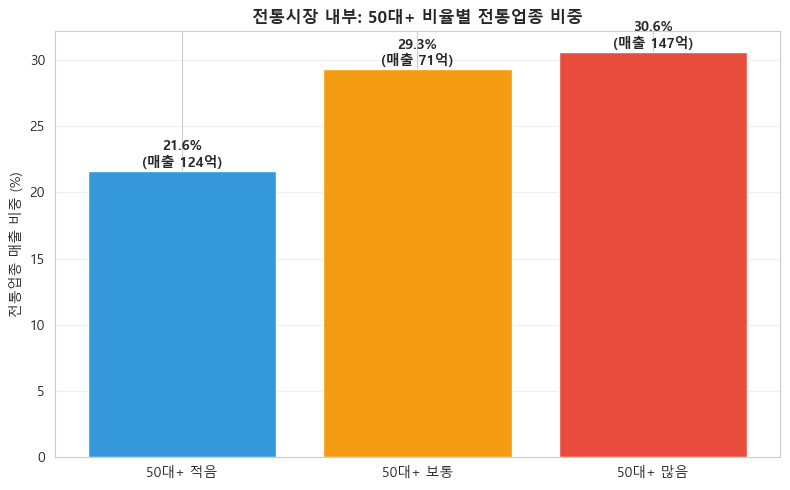

In [13]:
# 시각화
fig, ax = plt.subplots(figsize=(8, 5))
colors_3 = ['#3498DB', '#F39C12', '#E74C3C']
bars = ax.bar(전통구간['50대_수준'], 전통구간['전통업종'], color=colors_3, edgecolor='white')
ax.set_ylabel('전통업종 매출 비중 (%)')
ax.set_title('전통시장 내부: 50대+ 비율별 전통업종 비중', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
 
for bar, val, 매출 in zip(bars, 전통구간['전통업종'], 전통구간['전체매출억']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%\n(매출 {매출:.0f}억)', ha='center', fontsize=10, fontweight='bold')
 
plt.tight_layout()
plt.show()

2030 vs 50대+ 연령대 효과 비교

In [14]:
# 유동인구 2030 비율 추가
floating['2030_비율'] = (
    floating['연령대_20_유동인구_수'] + floating['연령대_30_유동인구_수']
) / floating['총_유동인구_수'].replace(0, np.nan) * 100
 
merged_compare = merged_50.merge(
    floating[['기준_년분기_코드', '상권_코드', '2030_비율']],
    on=['기준_년분기_코드', '상권_코드'], how='inner'
)

In [15]:
# 커피+주점+화장품 매출도 추가
타겟업종 = ['커피-음료', '호프-간이주점', '화장품']
타겟매출 = sales[sales['서비스_업종_코드_명'].isin(타겟업종)].groupby(
    ['기준_년분기_코드', '상권_코드']
)['당월_매출_금액'].sum().reset_index()
타겟매출.rename(columns={'당월_매출_금액': '타겟3_매출'}, inplace=True)
 
merged_compare = merged_compare.merge(타겟매출, on=['기준_년분기_코드', '상권_코드'], how='left').fillna(0)
merged_compare['타겟3_비중'] = merged_compare['타겟3_매출'] / merged_compare['전체_매출'] * 100

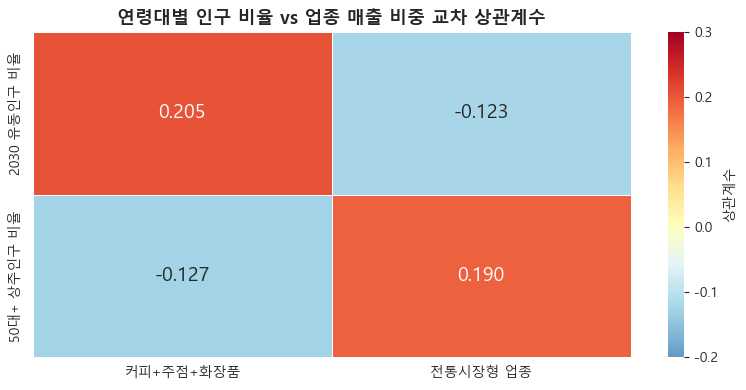

In [16]:
# 교차 상관계수 히트맵
cross_corr = pd.DataFrame({
    '커피+주점+화장품': [
        merged_compare[['2030_비율', '타겟3_비중']].corr().iloc[0,1],
        merged_compare[['50대이상_비율', '타겟3_비중']].corr().iloc[0,1]
    ],
    '전통시장형 업종': [
        merged_compare[['2030_비율', '전통업종_비중']].corr().iloc[0,1],
        merged_compare[['50대이상_비율', '전통업종_비중']].corr().iloc[0,1]
    ]
}, index=['2030 유동인구 비율', '50대+ 상주인구 비율'])
 
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(cross_corr, annot=True, fmt='.3f', cmap='RdYlBu_r',
            center=0, vmin=-0.2, vmax=0.3, ax=ax,
            linewidths=0.5, cbar_kws={'label': '상관계수'}, annot_kws={'size': 14})
ax.set_title('연령대별 인구 비율 vs 업종 매출 비중 교차 상관계수', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
 

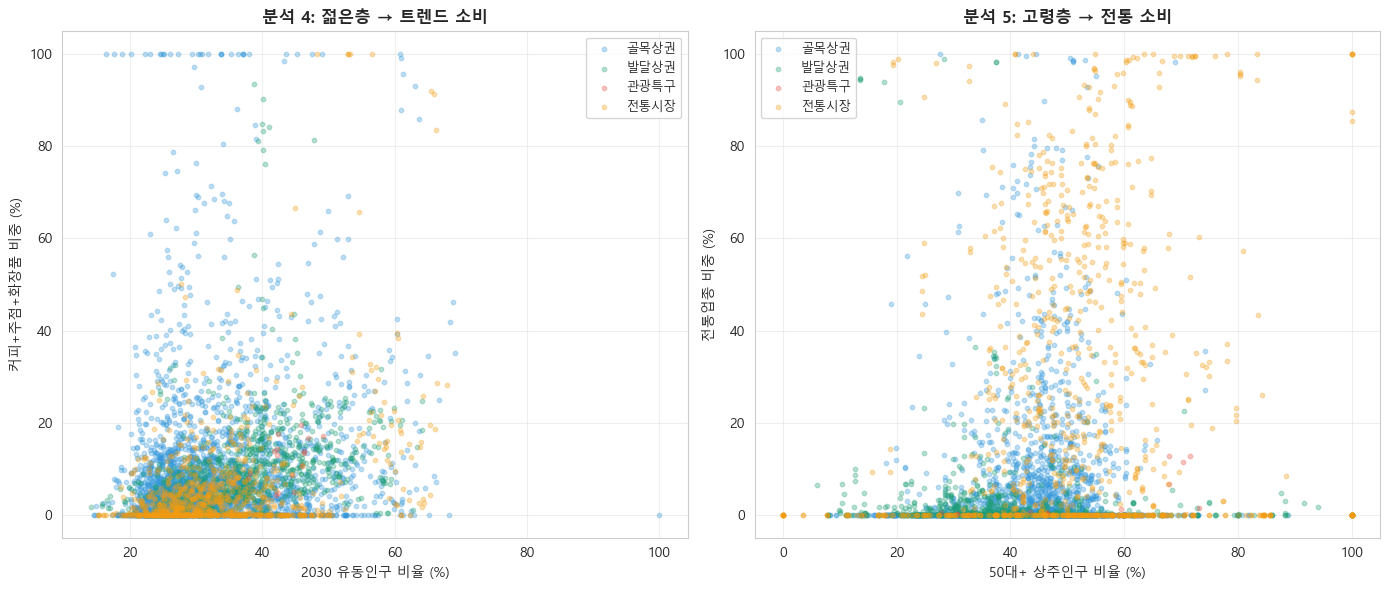

In [19]:
# %% 대비 산점도
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
sample_c = merged_compare.sample(n=min(5000, len(merged_compare)), random_state=42)
 
# (1) 2030 비율 vs 커피+주점+화장품
ax1 = axes[0]
for 구분 in 상권:
    sub = sample_c[sample_c['상권_구분_코드_명'] == 구분]
    ax1.scatter(sub['2030_비율'], sub['타겟3_비중'],
                alpha=0.3, s=10, color=색_map[구분], label=구분)
ax1.set_xlabel('2030 유동인구 비율 (%)')
ax1.set_ylabel('커피+주점+화장품 비중 (%)')
ax1.set_title('분석 4: 젊은층 → 트렌드 소비', fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)
 
# (2) 50대+ 비율 vs 전통업종
ax2 = axes[1]
for 구분 in 상권:
    sub = sample_c[sample_c['상권_구분_코드_명'] == 구분]
    ax2.scatter(sub['50대이상_비율'], sub['전통업종_비중'],
                alpha=0.3, s=10, color=색_map[구분], label=구분)
ax2.set_xlabel('50대+ 상주인구 비율 (%)')
ax2.set_ylabel('전통업종 비중 (%)')
ax2.set_title('분석 5: 고령층 → 전통 소비', fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)
 
plt.tight_layout()
plt.show()